In [1]:
import pandas as pd
import numpy as np
import time
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../results/smote_experiments', exist_ok=True)

LABEL_MAP   = {0: 'Benign', 1: 'DoS', 2: 'DDoS', 3: 'Mirai', 4: 'Spoofing'}
CLASS_NAMES = ['Benign', 'DoS', 'DDoS', 'Mirai', 'Spoofing']
ATTACK_NAMES = ['DoS', 'DDoS', 'Mirai', 'Spoofing']

print("Imports done.")

Imports done.


In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nClass distribution (train):\n{y_train.value_counts().sort_index().rename(LABEL_MAP)}")

X_train: (1062114, 30)
X_test:  (265529, 30)

Class distribution (train):
Label_encoded
Benign      318298
DoS         239759
DDoS        239095
Mirai       139403
Spoofing    125559
Name: count, dtype: int64


In [3]:
# Binary labels (Stage 1)
y_train_binary = y_train.apply(lambda x: 'Benign' if x == 0 else 'Attack')
y_test_binary  = y_test.apply(lambda x: 'Benign' if x == 0 else 'Attack')

le_binary = LabelEncoder()
y_train_binary_enc = le_binary.fit_transform(y_train_binary)
y_test_binary_enc  = le_binary.transform(y_test_binary)
print(f"Binary encoding: {dict(zip(le_binary.classes_, le_binary.transform(le_binary.classes_)))}")

# Attack-only rows (Stage 2)
attack_mask_train = y_train != 0
attack_mask_test  = y_test != 0
X_train_attack    = X_train[attack_mask_train]
y_train_attack    = y_train[attack_mask_train]
X_test_attack     = X_test[attack_mask_test]
y_test_attack     = y_test[attack_mask_test]

le_attack = LabelEncoder()
y_train_attack_enc = le_attack.fit_transform(y_train_attack)
y_test_attack_enc  = le_attack.transform(y_test_attack)
print(f"Attack encoding: {dict(zip(le_attack.classes_, le_attack.transform(le_attack.classes_)))}")

print(f"\nStage 2 class distribution (train):")
print(y_train_attack.value_counts().sort_index().rename(LABEL_MAP))

Binary encoding: {'Attack': np.int64(0), 'Benign': np.int64(1)}
Attack encoding: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3)}

Stage 2 class distribution (train):
Label_encoded
DoS         239759
DDoS        239095
Mirai       139403
Spoofing    125559
Name: count, dtype: int64


In [4]:
def evaluate_stage1(y_true_binary, y_pred_binary, y_true_multiclass):
    """Full Stage 1 metrics including per-attack-class FNR."""
    acc  = accuracy_score(y_true_binary, y_pred_binary)
    prec = precision_score(y_true_binary, y_pred_binary, pos_label='Attack')
    rec  = recall_score(y_true_binary, y_pred_binary, pos_label='Attack')
    f1   = f1_score(y_true_binary, y_pred_binary, pos_label='Attack')
    cm   = confusion_matrix(y_true_binary, y_pred_binary, labels=['Benign', 'Attack'])
    fnr  = cm[1][0] / (cm[1][0] + cm[1][1])  # overall attack FNR
    fpr  = cm[0][1] / (cm[0][0] + cm[0][1])  # benign misclassified as attack

    # per-attack-class FNR
    per_class_fnr = {}
    for label, name in LABEL_MAP.items():
        if label == 0:
            continue
        mask = y_true_multiclass == label
        missed = np.sum((y_true_multiclass[mask] == label) &
                        (np.array(y_pred_binary)[mask] == 'Benign'))
        total = mask.sum()
        per_class_fnr[name] = missed / total if total > 0 else 0

    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'fnr': fnr, 'fpr': fpr, 'per_class_fnr': per_class_fnr,
        'confusion_matrix': cm.tolist()
    }


def evaluate_stage2(y_true, y_pred):
    """Stage 2 macro metrics + per-class recall and F1."""
    labels = sorted(np.unique(y_true))
    acc    = accuracy_score(y_true, y_pred)
    prec   = precision_score(y_true, y_pred, average='macro')
    rec    = recall_score(y_true, y_pred, average='macro')
    f1     = f1_score(y_true, y_pred, average='macro')

    per_class = {}
    for l in labels:
        mask = y_true == l
        tp = np.sum((y_true == l) & (y_pred == l))
        fp = np.sum((y_true != l) & (y_pred == l))
        fn = np.sum((y_true == l) & (y_pred != l))
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f  = 2 * p * r / (p + r) if (p + r) > 0 else 0
        per_class[LABEL_MAP[l]] = {'precision': p, 'recall': r, 'f1': f}

    return {
        'accuracy': acc, 'precision_macro': prec,
        'recall_macro': rec, 'f1_macro': f1,
        'per_class': per_class
    }


def evaluate_pipeline(y_true, y_final_pred):
    """Full 5-class pipeline metrics."""
    all_labels = sorted(LABEL_MAP.keys())
    acc        = accuracy_score(y_true, y_final_pred)
    f1_macro   = f1_score(y_true, y_final_pred, average='macro')
    f1_weighted= f1_score(y_true, y_final_pred, average='weighted')
    cm         = confusion_matrix(y_true, y_final_pred, labels=all_labels)
    fnr        = np.sum((y_true != 0) & (y_final_pred == 0)) / np.sum(y_true != 0)
    fpr        = np.sum((y_true == 0) & (y_final_pred != 0)) / np.sum(y_true == 0)

    return {
        'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'fnr': fnr, 'fpr': fpr, 'confusion_matrix': cm.tolist()
    }


def run_pipeline(X_tr_s1, y_tr_s1_enc, X_tr_s2, y_tr_s2_enc,
                 label=''):
    """Train RF Stage 1 + BRF Stage 2, return all metrics."""
    print(f"\n{'='*55}")
    print(f"Running: {label}")
    print(f"{'='*55}")
    print(f"  S1 train shape: {X_tr_s1.shape} | classes: {np.unique(y_tr_s1_enc, return_counts=True)}")
    print(f"  S2 train shape: {X_tr_s2.shape} | classes: {np.unique(y_tr_s2_enc, return_counts=True)}")

    # Stage 1 — RF
    t0   = time.time()
    rf   = RandomForestClassifier(random_state=42, n_jobs=-1)
    rf.fit(X_tr_s1, y_tr_s1_enc)
    s1_time = time.time() - t0

    s1_pred_enc = rf.predict(X_test)
    s1_pred     = le_binary.inverse_transform(s1_pred_enc)
    s1_metrics  = evaluate_stage1(y_test_binary, s1_pred, y_test.values)
    print(f"  Stage 1 done ({s1_time:.1f}s) | FNR: {s1_metrics['fnr']:.4f}")

    # Stage 2 — BRF
    t0   = time.time()
    brf  = BalancedRandomForestClassifier(random_state=42, n_jobs=-1,
                                           n_estimators=50, max_depth=20)
    brf.fit(X_tr_s2, y_tr_s2_enc)
    s2_time = time.time() - t0

    s2_pred_enc = brf.predict(X_test_attack)
    s2_pred     = le_attack.inverse_transform(s2_pred_enc)
    s2_metrics  = evaluate_stage2(y_test_attack.values, s2_pred)
    print(f"  Stage 2 done ({s2_time:.1f}s) | Macro F1: {s2_metrics['f1_macro']:.4f}")

    # Combined pipeline
    final_pred = np.empty(len(y_test), dtype=object)
    benign_idx = np.where(s1_pred == 'Benign')[0]
    attack_idx = np.where(s1_pred == 'Attack')[0]
    final_pred[benign_idx] = 0
    if len(attack_idx) > 0:
        s2_enc = brf.predict(X_test.iloc[attack_idx])
        final_pred[attack_idx] = le_attack.inverse_transform(s2_enc)
    final_pred   = final_pred.astype(int)
    pipe_metrics = evaluate_pipeline(y_test.values, final_pred)
    print(f"  Pipeline done | Acc: {pipe_metrics['accuracy']:.4f} | "
          f"F1: {pipe_metrics['f1_macro']:.4f} | FNR: {pipe_metrics['fnr']:.4f}")

    return {
        'stage1': s1_metrics,
        'stage2': s2_metrics,
        'pipeline': pipe_metrics,
        'label': label
    }


print("Helper functions ready.")

Helper functions ready.


In [5]:
# H0 results copied from 04_hierarchical_final.ipynb
# No retraining needed — these are your confirmed numbers

H0 = {
    'label': 'H0: RF + BRF (no SMOTE)',
    'stage1': {
        'accuracy': 0.9047, 'precision': 0.9376, 'recall': 0.9256,
        'f1': 0.9315, 'fnr': 0.0744, 'fpr': 0.1440,
        'per_class_fnr': {
            'DoS': None, 'DDoS': None, 'Mirai': None, 'Spoofing': None
        }
    },
    'stage2': {
        'accuracy': 0.8954, 'precision_macro': 0.8767,
        'recall_macro': 0.8917, 'f1_macro': 0.8818,
        'per_class': {
            'DoS':      {'precision': 0.95, 'recall': 0.86, 'f1': 0.90},
            'DDoS':     {'precision': 0.97, 'recall': 0.96, 'f1': 0.97},
            'Mirai':    {'precision': 0.75, 'recall': 0.83, 'f1': 0.79},
            'Spoofing': {'precision': 0.79, 'recall': 0.84, 'f1': 0.81}
        }
    },
    'pipeline': {
        'accuracy': 0.8459, 'f1_macro': 0.8229,
        'f1_weighted': 0.8483, 'fnr': 0.0744, 'fpr': None
    }
}

print("H0 baseline loaded.")

H0 baseline loaded.


In [6]:
# SMOTE on binary training data (Benign vs Attack)
print("Applying SMOTE to binary Stage 1 data...")
print(f"Before: {pd.Series(y_train_binary_enc).value_counts().to_dict()}")

smote_binary = SMOTE(random_state=42, k_neighbors=5)
X_train_h1, y_train_h1 = smote_binary.fit_resample(X_train, y_train_binary_enc)

print(f"After:  {pd.Series(y_train_h1).value_counts().to_dict()}")

H1 = run_pipeline(
    X_tr_s1=X_train_h1,
    y_tr_s1_enc=y_train_h1,
    X_tr_s2=X_train_attack,
    y_tr_s2_enc=y_train_attack_enc,
    label='H1: Binary SMOTE S1 + BRF S2'
)

Applying SMOTE to binary Stage 1 data...
Before: {0: 743816, 1: 318298}
After:  {0: 743816, 1: 743816}

Running: H1: Binary SMOTE S1 + BRF S2
  S1 train shape: (1487632, 30) | classes: (array([0, 1]), array([743816, 743816]))
  S2 train shape: (743816, 30) | classes: (array([0, 1, 2, 3]), array([239759, 239095, 139403, 125559]))
  Stage 1 done (79.2s) | FNR: 0.0828
  Stage 2 done (17.7s) | Macro F1: 0.8818
  Pipeline done | Acc: 0.8484 | F1: 0.8244 | FNR: 0.0828


In [7]:
# Oversample Mirai and Spoofing up to DoS/DDoS level (~300,000)
# BEFORE merging attack labels into binary
print("Applying subclass-aware SMOTE to Stage 1...")
print(f"Before:\n{y_train.value_counts().sort_index().rename(LABEL_MAP)}")

# Target: bring Mirai and Spoofing up to 300,000 (matches DoS/DDoS)
target_count = 300000
sampling_strategy = {}
for label in [3, 4]:  # Mirai=3, Spoofing=4
    current = (y_train == label).sum()
    if current < target_count:
        sampling_strategy[label] = target_count

smote_subclass = SMOTE(random_state=42, k_neighbors=5,
                        sampling_strategy=sampling_strategy)
X_train_h2_5class, y_train_h2_5class = smote_subclass.fit_resample(
    X_train, y_train
)

print(f"After (5-class):\n{pd.Series(y_train_h2_5class).value_counts().sort_index().rename(LABEL_MAP)}")

# Now collapse to binary
y_train_h2_binary = pd.Series(y_train_h2_5class).apply(
    lambda x: 'Benign' if x == 0 else 'Attack'
)
y_train_h2_binary_enc = le_binary.transform(y_train_h2_binary)

print(f"After (binary): {pd.Series(y_train_h2_binary_enc).value_counts().to_dict()}")

H2 = run_pipeline(
    X_tr_s1=X_train_h2_5class,
    y_tr_s1_enc=y_train_h2_binary_enc,
    X_tr_s2=X_train_attack,
    y_tr_s2_enc=y_train_attack_enc,
    label='H2: Subclass-Aware SMOTE S1 + BRF S2'
)

Applying subclass-aware SMOTE to Stage 1...
Before:
Label_encoded
Benign      318298
DoS         239759
DDoS        239095
Mirai       139403
Spoofing    125559
Name: count, dtype: int64
After (5-class):
Label_encoded
Benign      318298
DoS         239759
DDoS        239095
Mirai       300000
Spoofing    300000
Name: count, dtype: int64
After (binary): {0: 1078854, 1: 318298}

Running: H2: Subclass-Aware SMOTE S1 + BRF S2
  S1 train shape: (1397152, 30) | classes: (array([0, 1]), array([1078854,  318298]))
  S2 train shape: (743816, 30) | classes: (array([0, 1, 2, 3]), array([239759, 239095, 139403, 125559]))
  Stage 1 done (75.0s) | FNR: 0.0672
  Stage 2 done (17.2s) | Macro F1: 0.8818
  Pipeline done | Acc: 0.8412 | F1: 0.8198 | FNR: 0.0672


In [8]:
# SMOTE on attack-only training data — balance Mirai/Spoofing to DoS/DDoS level
print("Applying SMOTE to Stage 2 attack-only data...")
print(f"Before:\n{y_train_attack.value_counts().sort_index().rename(LABEL_MAP)}")

# Target: bring all classes to ~239,759 (max in attack subset)
smote_s2 = SMOTE(random_state=42, k_neighbors=5)
X_train_h3_s2, y_train_h3_s2 = smote_s2.fit_resample(
    X_train_attack, y_train_attack_enc
)

print(f"After: {pd.Series(y_train_h3_s2).value_counts().to_dict()}")
print(f"  (encoded labels — 0=DoS, 1=DDoS, 2=Mirai, 3=Spoofing)")

H3 = run_pipeline(
    X_tr_s1=X_train,
    y_tr_s1_enc=y_train_binary_enc,
    X_tr_s2=X_train_h3_s2,
    y_tr_s2_enc=y_train_h3_s2,
    label='H3: RF S1 (no SMOTE) + SMOTE S2'
)

Applying SMOTE to Stage 2 attack-only data...
Before:
Label_encoded
DoS         239759
DDoS        239095
Mirai       139403
Spoofing    125559
Name: count, dtype: int64
After: {2: 239759, 0: 239759, 1: 239759, 3: 239759}
  (encoded labels — 0=DoS, 1=DDoS, 2=Mirai, 3=Spoofing)

Running: H3: RF S1 (no SMOTE) + SMOTE S2
  S1 train shape: (1062114, 30) | classes: (array([0, 1]), array([743816, 318298]))
  S2 train shape: (959036, 30) | classes: (array([0, 1, 2, 3]), array([239759, 239759, 239759, 239759]))
  Stage 1 done (44.1s) | FNR: 0.0744
  Stage 2 done (36.1s) | Macro F1: 0.8807
  Pipeline done | Acc: 0.8456 | F1: 0.8221 | FNR: 0.0744


In [9]:
# Combine H2 Stage 1 data with H3 Stage 2 data
print("H4: Full SMOTE-enhanced hierarchy...")

# Stage 2 attack-only from the H2 5-class oversampled data
attack_mask_h2 = y_train_h2_5class != 0
X_train_h4_s2_raw = X_train_h2_5class[attack_mask_h2]
y_train_h4_s2_raw = y_train_h2_5class[attack_mask_h2]

le_attack_h4 = LabelEncoder()
y_train_h4_s2_enc = le_attack_h4.fit_transform(y_train_h4_s2_raw)

# Apply SMOTE on this attack subset too
smote_h4 = SMOTE(random_state=42, k_neighbors=5)
X_train_h4_s2, y_train_h4_s2 = smote_h4.fit_resample(
    X_train_h4_s2_raw, y_train_h4_s2_enc
)

print(f"Stage 2 distribution after SMOTE: {pd.Series(y_train_h4_s2).value_counts().to_dict()}")

# For H4 we need a custom pipeline since Stage 2 uses a different encoder
print(f"\nTraining H4 pipeline...")

t0  = time.time()
rf_h4 = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_h4.fit(X_train_h2_5class, y_train_h2_binary_enc)
s1_time = time.time() - t0

s1_pred_enc = rf_h4.predict(X_test)
s1_pred     = le_binary.inverse_transform(s1_pred_enc)
s1_metrics_h4 = evaluate_stage1(y_test_binary, s1_pred, y_test.values)
print(f"Stage 1 done ({s1_time:.1f}s) | FNR: {s1_metrics_h4['fnr']:.4f}")

t0   = time.time()
brf_h4 = BalancedRandomForestClassifier(random_state=42, n_jobs=-1,
                                          n_estimators=50, max_depth=20)
brf_h4.fit(X_train_h4_s2, y_train_h4_s2)
s2_time = time.time() - t0

# Stage 2 eval — need to use le_attack_h4 for inverse transform
s2_pred_enc_h4 = brf_h4.predict(X_test_attack)
s2_pred_h4     = le_attack_h4.inverse_transform(s2_pred_enc_h4)
s2_metrics_h4  = evaluate_stage2(y_test_attack.values, s2_pred_h4)
print(f"Stage 2 done ({s2_time:.1f}s) | Macro F1: {s2_metrics_h4['f1_macro']:.4f}")

# Combined pipeline
final_pred_h4 = np.empty(len(y_test), dtype=object)
benign_idx = np.where(s1_pred == 'Benign')[0]
attack_idx = np.where(s1_pred == 'Attack')[0]
final_pred_h4[benign_idx] = 0
if len(attack_idx) > 0:
    s2_enc = brf_h4.predict(X_test.iloc[attack_idx])
    final_pred_h4[attack_idx] = le_attack_h4.inverse_transform(s2_enc)
final_pred_h4   = final_pred_h4.astype(int)
pipe_metrics_h4 = evaluate_pipeline(y_test.values, final_pred_h4)
print(f"Pipeline done | Acc: {pipe_metrics_h4['accuracy']:.4f} | "
      f"F1: {pipe_metrics_h4['f1_macro']:.4f} | FNR: {pipe_metrics_h4['fnr']:.4f}")

H4 = {
    'label': 'H4: Subclass-Aware SMOTE S1 + SMOTE S2',
    'stage1': s1_metrics_h4,
    'stage2': s2_metrics_h4,
    'pipeline': pipe_metrics_h4
}

H4: Full SMOTE-enhanced hierarchy...
Stage 2 distribution after SMOTE: {2: 300000, 0: 300000, 1: 300000, 3: 300000}

Training H4 pipeline...
Stage 1 done (67.6s) | FNR: 0.0672
Stage 2 done (48.5s) | Macro F1: 0.8811
Pipeline done | Acc: 0.8410 | F1: 0.8190 | FNR: 0.0672


In [10]:
experiments = [H0, H1, H2, H3, H4]

# ── Table 1: Full pipeline comparison ───────────────────────────────────────
print("\n" + "="*70)
print("TABLE 1: FULL PIPELINE COMPARISON")
print("="*70)
print(f"{'Config':<40} {'Accuracy':>10} {'Macro F1':>10} {'FNR':>8}")
print("-"*70)
for exp in experiments:
    p = exp['pipeline']
    print(f"{exp['label']:<40} "
          f"{p['accuracy']:>10.4f} "
          f"{p['f1_macro']:>10.4f} "
          f"{p['fnr']:>8.4f}")

# ── Table 2: Stage 1 per-class FNR ──────────────────────────────────────────
print("\n" + "="*70)
print("TABLE 2: STAGE 1 PER-ATTACK-CLASS FNR")
print("="*70)
print(f"{'Config':<40} {'DoS':>8} {'DDoS':>8} {'Mirai':>8} {'Spoofing':>8}")
print("-"*70)
for exp in experiments:
    pcf = exp['stage1']['per_class_fnr']
    dos  = f"{pcf['DoS']:.4f}"  if pcf.get('DoS')  is not None else 'N/A'
    ddos = f"{pcf['DDoS']:.4f}" if pcf.get('DDoS') is not None else 'N/A'
    mir  = f"{pcf['Mirai']:.4f}" if pcf.get('Mirai') is not None else 'N/A'
    spo  = f"{pcf['Spoofing']:.4f}" if pcf.get('Spoofing') is not None else 'N/A'
    print(f"{exp['label']:<40} {dos:>8} {ddos:>8} {mir:>8} {spo:>8}")

# ── Table 3: Stage 2 per-class F1 ───────────────────────────────────────────
print("\n" + "="*70)
print("TABLE 3: STAGE 2 PER-CLASS F1")
print("="*70)
print(f"{'Config':<40} {'DoS':>8} {'DDoS':>8} {'Mirai':>8} {'Spoofing':>8}")
print("-"*70)
for exp in experiments:
    pc = exp['stage2']['per_class']
    print(f"{exp['label']:<40} "
          f"{pc['DoS']['f1']:>8.4f} "
          f"{pc['DDoS']['f1']:>8.4f} "
          f"{pc['Mirai']['f1']:>8.4f} "
          f"{pc['Spoofing']['f1']:>8.4f}")


TABLE 1: FULL PIPELINE COMPARISON
Config                                     Accuracy   Macro F1      FNR
----------------------------------------------------------------------
H0: RF + BRF (no SMOTE)                      0.8459     0.8229   0.0744
H1: Binary SMOTE S1 + BRF S2                 0.8484     0.8244   0.0828
H2: Subclass-Aware SMOTE S1 + BRF S2         0.8412     0.8198   0.0672
H3: RF S1 (no SMOTE) + SMOTE S2              0.8456     0.8221   0.0744
H4: Subclass-Aware SMOTE S1 + SMOTE S2       0.8410     0.8190   0.0672

TABLE 2: STAGE 1 PER-ATTACK-CLASS FNR
Config                                        DoS     DDoS    Mirai Spoofing
----------------------------------------------------------------------
H0: RF + BRF (no SMOTE)                       N/A      N/A      N/A      N/A
H1: Binary SMOTE S1 + BRF S2               0.0457   0.0065   0.1162   0.2619
H2: Subclass-Aware SMOTE S1 + BRF S2       0.0391   0.0058   0.0950   0.2068
H3: RF S1 (no SMOTE) + SMOTE S2            0

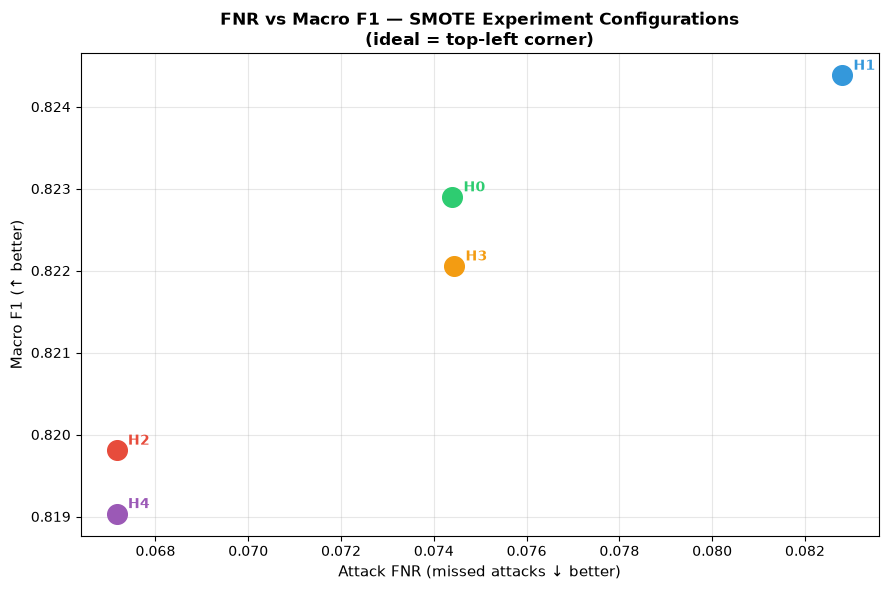

Saved: fnr_vs_f1.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
labels = [e['label'].split(':')[0] for e in experiments]

for exp, color, label in zip(experiments, colors, labels):
    fnr = exp['pipeline']['fnr']
    f1  = exp['pipeline']['f1_macro']
    ax.scatter(fnr, f1, color=color, s=200, zorder=5)
    ax.annotate(label, (fnr, f1), textcoords='offset points',
                xytext=(8, 4), fontsize=10, fontweight='bold', color=color)

ax.set_xlabel('Attack FNR (missed attacks ↓ better)', fontsize=11)
ax.set_ylabel('Macro F1 (↑ better)', fontsize=11)
ax.set_title('FNR vs Macro F1 — SMOTE Experiment Configurations\n(ideal = top-left corner)',
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/smote_experiments/fnr_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fnr_vs_f1.png")

In [12]:
def make_json_safe(d):
    if isinstance(d, dict):  return {k: make_json_safe(v) for k, v in d.items()}
    if isinstance(d, list):  return [make_json_safe(v) for v in d]
    if isinstance(d, (np.integer,)):  return int(d)
    if isinstance(d, (np.floating,)): return float(d)
    if d is None: return None
    return d

all_results = {e['label']: make_json_safe(e) for e in experiments}

with open('../results/smote_experiments/smote_experiment_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print("✓ Saved to ../results/smote_experiments/smote_experiment_results.json")
print("✓ Figure saved to ../results/smote_experiments/fnr_vs_f1.png")

✓ Saved to ../results/smote_experiments/smote_experiment_results.json
✓ Figure saved to ../results/smote_experiments/fnr_vs_f1.png
